In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.chdir('/content/drive/MyDrive/hackathon_project')

In [3]:
!pwd

/content/drive/MyDrive/hackathon_project


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset directly into your folder
# Note: Replace 'dataset-name' with the actual slug from the Kaggle URL
!kaggle datasets download -d abdullahkhanuet22/road-classification --unzip

Dataset URL: https://www.kaggle.com/datasets/abdullahkhanuet22/road-classification
License(s): CC0-1.0
100% 28.9M/28.9M [00:00<00:00, 200MB/s]



In [ ]:
!mkdir -p data/{raw,masks,synthetic/{images,labels}} models/{checkpoints,sam_weights} src notebooks && touch src/{generate.py,segment.py,dataset.py,train.py} notebooks/visualize.ipynb requirements.txt config.yaml

In [ ]:
!kaggle datasets download -d abdullahkhanuet22/road-classification --unzip

Dataset URL: https://www.kaggle.com/datasets/abdullahkhanuet22/road-classification
License(s): CC0-1.0
100% 28.9M/28.9M [00:00<00:00, 192MB/s]



In [ ]:
!kaggle datasets download -d muskanverma24/pothole-detection-dataset-yolov11-optimized --unzip

Dataset URL: https://www.kaggle.com/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized
License(s): Attribution 4.0 International (CC BY 4.0)
100% 215M/215M [00:01<00:00, 141MB/s]

User cancelled operation


In [ ]:
!nvidia-smi

Sat Apr  4 09:00:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [25]:
!python src/generate.py

🔍 Checking Input Path: /content/drive/MyDrive/hackathon_project/data/raw/Road Classification
📁 Saving Output To: /content/drive/MyDrive/hackathon_project/data/synthetic/images
✅ Found 110 images in 'Broken'
/content/drive/MyDrive/hackathon_project/src/generate.py:24: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
✅ Found 94 images in 'Not Broken'

--- Process Complete ---
Total synthetic images generated: 204


In [1]:
! pip install split-folders

In [10]:
!python src/split_data.py

Spliting data from data/synthetic/images...
Copying files: 204 files [00:45,  4.46 files/s]
✅ Success! Data split into:
 - data/processed/train
 - data/processed/val


In [12]:
!python src/augment_generative.py

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading Stable Diffusion (this takes a minute)...
Loading pipeline components...:   0% 0/7 [00:00<?, ?it/s]An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  14% 1/7 [00:13<01:18, 13.02s/it]
Loading weights:   0% 0/196 [00:00<?, ?it/s]
Loading weights:

In [14]:
!python src/train.py

/content/drive/MyDrive/hackathon_project/src/train.py:60: UserWarning: Argument(s) 'num_shadows_lower, num_shadows_upper' are not valid for transform RandomShadow
  A.RandomShadow(num_shadows_lower=1, num_shadows_upper=3, shadow_dimension=5, p=0.5),
🚀 Training Shadow-Proof Model on: cuda:0
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 158MB/s]
Epoch 1/15
train Loss: 0.5979 Acc: 0.6517
val Loss: 0.4662 Acc: 0.7317
Epoch 2/15
train Loss: 0.3935 Acc: 0.7978
val Loss: 0.4634 Acc: 0.7317
Epoch 3/15
train Loss: 0.2781 Acc: 0.8708
val Loss: 0.5518 Acc: 0.7317
Epoch 4/15
train Loss: 0.1746 Acc: 0.9382
val Loss: 0.4853 Acc: 0.7317
Epoch 5/15
train Loss: 0.1247 Acc: 0.9719
val Loss: 0.4275 Acc: 0.8049
Epoch 6/15
train Loss: 0.1454 Acc: 0.9326
val Loss: 0.4032 Acc: 0.8049
Epoch 7/15
train Loss: 0.1175 Acc: 0.9719
val Loss: 0.4276 Acc: 0.7805
Epoch 8/15
train Loss: 0.1124 Acc: 0.96

In [15]:
!python src/predict.py

In [4]:
!python src/simulate_hazard.py

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--r

Generating pothole simulation...


  0%|          | 0/30 [00:00<?, ?it/s]

Analysis saved to test_step_2.jpg
🚀 SUCCESS! Showing the predicted hazard outline:


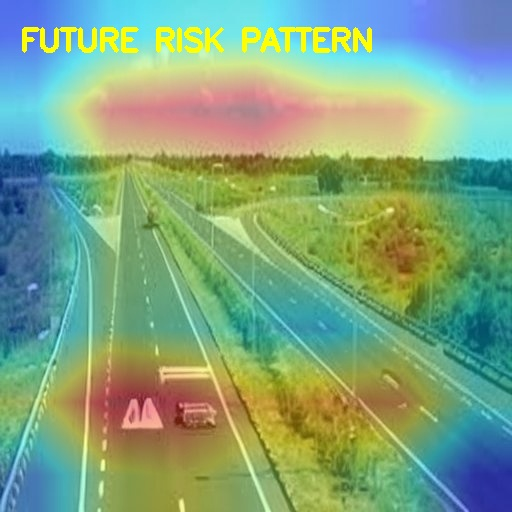

In [18]:
from src.simulate_hazard import RoadHazardSimulator
from src.future_vision import FutureRoadAnalyzer
from google.colab.patches import cv2_imshow
import cv2
import os

# 1. Initialize
sim = RoadHazardSimulator()
vision = FutureRoadAnalyzer()

# 2. Set your input filename (MAKE SURE THIS MATCHES YOUR UPLOADED FILE)
input_file = "clean_road.jpeg" # Change this if your uploaded file has a different name

if not os.path.exists(input_file):
    print(f"❌ ERROR: I can't find '{input_file}' in your folder. Please upload it first!")
else:
    # 3. Simulate the hazard
    # This creates 'simulated_road.jpg'
    sim_path = sim.simulate(input_file, hazard_type="pothole", output_path="test_step_1.jpg")

    # 4. Analyze with the 'Glow' Heatmap
    # This creates 'final_glow_analysis.jpg'
    vision.visualize("test_step_1.jpg", output_path="test_step_2.jpg")

    # 5. Show the result
    final_img = cv2.imread("test_step_2.jpg")

    if final_img is not None:
        print("🚀 SUCCESS! Showing the predicted hazard outline:")
        cv2_imshow(final_img)
    else:
        print("❌ Something went wrong during the save process.")